In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import time

In [2]:
fake_news_data = os.path.join(os.getcwd(), "Fake.csv")
true_news_data = os.path.join(os.getcwd(), "True.csv")

df_fake = pd.read_csv(fake_news_data)
df_true = pd.read_csv(true_news_data)


In [3]:
print("fake news data shape: ", df_fake.shape)
print("true news data shape: ", df_true.shape)   

fake news data shape:  (23481, 4)
true news data shape:  (21417, 4)


In [4]:
print("fake news columns: ", df_fake.columns.tolist())
print("true news columns: ", df_true.columns.tolist())

fake news columns:  ['title', 'text', 'subject', 'date']
true news columns:  ['title', 'text', 'subject', 'date']


In [5]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
df_fake.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
df_true.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:
df_fake.info()
print("--------------------------------")
print("--------------------------------")
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
--------------------------------
--------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [14]:
df_fake['label'] = 0  # Fake news
df_true['label'] = 1  # Real news

df = pd.concat([df_fake, df_true], axis=0).reset_index(drop=True)


In [15]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/arif/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word.lower() not in stop_words])

# Apply to both datasets
df['clean_text'] = df['text'].apply(remove_stopwords)

In [17]:
df.head()

,title,text,subject,date,word_count,char_count,num_exclamations,label,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",495,2893,6,0,Donald Trump wish Americans Happy New Year lea...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",305,1898,0,0,House Intelligence Committee Chairman Devin Nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",580,3597,2,0,"Friday, revealed former Milwaukee Sheriff Davi..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",444,2774,0,0,"Christmas day, Donald Trump announced would ba..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",420,2346,0,0,Pope Francis used annual Christmas Day message...


In [18]:
import re

def count_words(text):
    return len(str(text).split())

def count_chars(text):
    return len(str(text))

def count_exclamations(text):
    return str(text).count('!')

df_fake['word_count'] = df_fake['text'].apply(count_words)
df_fake['char_count'] = df_fake['text'].apply(count_chars)
df_fake['num_exclamations'] = df_fake['text'].apply(count_exclamations)

df_true['word_count'] = df_true['text'].apply(count_words)
df_true['char_count'] = df_true['text'].apply(count_chars)
df_true['num_exclamations'] = df_true['text'].apply(count_exclamations)

# Compare means
print("Fake news stats:\n", df_fake[['word_count','char_count','num_exclamations']].mean())
print("Real news stats:\n", df_true[['word_count','char_count','num_exclamations']].mean())


Fake news stats:
 word_count           423.197905
char_count          2547.396235
num_exclamations       0.722968
dtype: float64
Real news stats:
 word_count           385.640099
char_count          2383.278517
num_exclamations       0.061913
dtype: float64


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Fake news top words
vec_fake = CountVectorizer(max_features=50)
fake_counts = vec_fake.fit_transform(df_fake['text'])
fake_words = pd.DataFrame(fake_counts.toarray(), columns=vec_fake.get_feature_names_out()).sum().sort_values(ascending=False)


# Real news top words
vec_real = CountVectorizer(max_features=50)
real_counts = vec_real.fit_transform(df_true['text'])
real_words = pd.DataFrame(real_counts.toarray(), columns=vec_real.get_feature_names_out()).sum().sort_values(ascending=False)



In [12]:
fake_words

the          543551
to           290819
of           236640
and          226971
in           171163
that         151662
is           111234
for           93480
on            83591
it            83380
trump         79300
he            78997
was           67857
with          63419
his           58351
this          58217
as            57768
be            49271
by            47903
are           46475
have          46095
they          45697
not           45634
who           42437
at            42394
has           42317
you           41218
from          41035
we            39178
an            35130
but           34187
said          33763
about         33025
their         30290
president     27715
people        26570
she           26364
her           26087
all           25647
what          25295
or            24993
one           24531
will          24182
out           23773
would         23562
if            23247
been          23036
more          22785
when          22168
were          21617


In [13]:
real_words

the           482468
to            245734
of            205275
and           182081
in            181652
on            108594
said           99062
that           88237
for            79895
is             55494
trump          54700
with           54504
he             54370
it             49590
by             47949
was            47946
as             47330
has            46246
from           39383
his            38018
have           36426
not            36197
be             34427
at             33214
an             32718
would          31605
reuters        28976
president      28177
who            27645
but            26617
are            26143
had            25675
will           25254
we             22166
they           22067
its            21323
this           21069
state          21025
which          20809
been           19605
after          19403
were           18918
government     18846
about          17477
more           17232
new            16917
their          16827
states       

In [20]:
vec = CountVectorizer(max_features=50)
df_counts = vec.fit_transform(df['clean_text'])
df_words = pd.DataFrame(df_counts.toarray(), columns=vec.get_feature_names_out()).sum().sort_values(ascending=False)

df_words

trump         134000
said          132825
president      55892
would          55167
people         41857
one            37927
state          34488
also           31357
new            31311
reuters        29425
clinton        28695
obama          28203
donald         28127
government     28048
house          27753
states         26843
republican     25568
year           24998
could          23957
united         23601
told           23367
like           22774
white          22745
the            22659
two            21825
campaign       21743
time           21265
election       21240
last           20985
party          20709
news           20652
it             20413
first          19412
washington     18725
country        18119
even           17940
former         17906
us             17218
hillary        16865
years          16697
many           16669
american       16207
media          16121
security       15975
law            15793
made           15540
may            15533
national     

In [22]:

def capitalization_features(text):
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series([0,0,0])

    # total characters
    total_chars = len(text)
    upper_chars = sum(1 for c in text if c.isupper())

    # words
    words = text.split()
    total_words = len(words)
    upper_words = sum(1 for w in words if w.isupper())

    # features
    pct_upper_chars = upper_chars / total_chars
    pct_upper_words = upper_words / total_words if total_words > 0 else 0
    all_caps = int(text.isupper())

    return pd.Series([pct_upper_chars, pct_upper_words, all_caps])

df[['pct_upper_chars', 'pct_upper_words', 'all_caps']] = df['text'].apply(capitalization_features)


In [23]:
corr = df[['pct_upper_chars', 'pct_upper_words', 'all_caps', 'label']].corr()
print(corr['label'])

pct_upper_chars   -0.054005
pct_upper_words   -0.058033
all_caps          -0.028873
label              1.000000
Name: label, dtype: float64


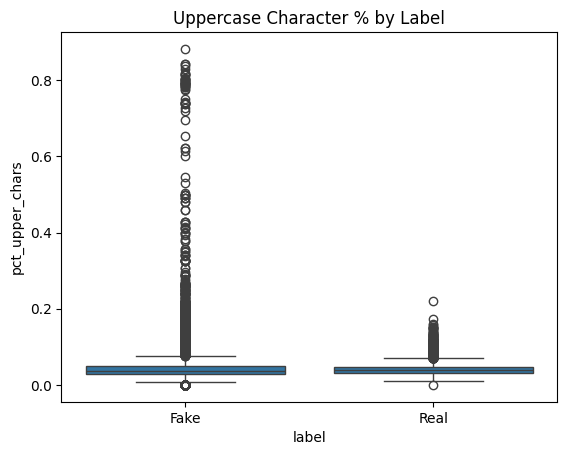

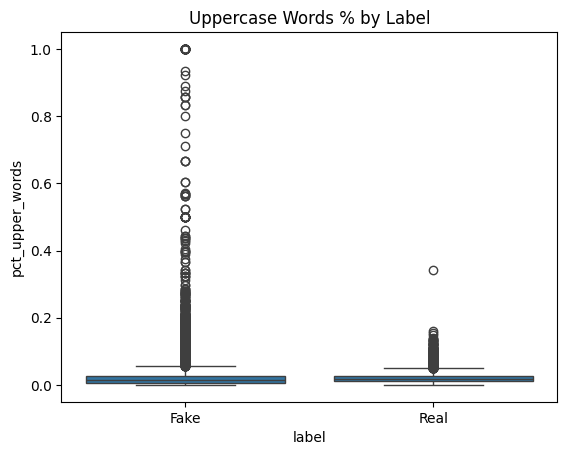

In [24]:
sns.boxplot(x='label', y='pct_upper_chars', data=df)
plt.xticks([0,1], ['Fake','Real'])
plt.title("Uppercase Character % by Label")
plt.show()

sns.boxplot(x='label', y='pct_upper_words', data=df)
plt.xticks([0,1], ['Fake','Real'])
plt.title("Uppercase Words % by Label")
plt.show()